# Paper Figure 5 — barycentric projection map

The known Section 7.1 mixtures are used directly. Samples are only evaluation
points. Each lambda is solved once, and the exact same coupling is reused for
its map and all five interpolation panels in the two-row paper layout.


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pgot import set_reproducible

set_reproducible()
OUTPUT_DIR = Path("outputs")
METADATA_DIR = Path("metadata")
OUTPUT_DIR.mkdir(exist_ok=True)
METADATA_DIR.mkdir(exist_ok=True)


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from pgot import (
    DEFAULT_SEED,
    GaussianMixture,
    make_figure5,
    sample_from_gmm,
    solve_figure5,
    write_figure_sidecar,
)

# ---------------------------------------------------------------
# Section 7.1 mixtures. These values are the experiment: they are
# written here, not imported, so that the published page can be
# checked against the paper directly.
# ---------------------------------------------------------------
source = GaussianMixture(
    np.array([0.5, 0.5]),                                    # alpha_A
    np.array([[-8.0, -5.0], [1.0, -8.0]]),                   # m_A^(1), m_A^(2)
    0.2 * np.array([[[1.0, 0.2], [0.2, 1.0]],                # Sigma_A^(1)
                    [[1.0, -0.1], [-0.1, 1.0]]]),            # Sigma_A^(2)
)
target = GaussianMixture(
    np.array([0.45, 0.45, 0.1]),                             # alpha_B
    np.array([[-3.5, 3.5], [3.5, 3.5], [9.0, 7.5]]),         # m_B^(1..3)
    0.2 * np.array([[[1.0, -0.1], [-0.1, 1.0]],              # Sigma_B^(1)
                    [[1.0, 0.2], [0.2, 1.0]],                # Sigma_B^(2)
                    [[1.0, 0.0], [0.0, 1.0]]]),              # Sigma_B^(3), isotropic
)

# Section 7.1.5: 2000 samples from each mixture, used only as evaluation
# points for the map and as the scatter overlay.
SAMPLES_PER_MIXTURE = 2000
source_points = sample_from_gmm(
    source.weights, source.comp_mean, source.comp_cov, SAMPLES_PER_MIXTURE,
    rng=np.random.default_rng(DEFAULT_SEED + 10),
)
target_points = sample_from_gmm(
    target.weights, target.comp_mean, target.comp_cov, SAMPLES_PER_MIXTURE,
    rng=np.random.default_rng(DEFAULT_SEED + 11),
)


In [3]:
# Section 7.1.5: lambda in {0.25, 0.5} at a fixed epsilon = 0.03
FIGURE5_LAMBDAS = [0.25, 0.5]
FIGURE5_EPSILON = 0.03
FIGURE5_TIMES = [0.2, 0.4, 0.6, 0.8, 1.0]
figure5_records = solve_figure5(
    source_points,
    source,
    target,
    lambdas=FIGURE5_LAMBDAS,
    epsilon=FIGURE5_EPSILON,
)
for record in figure5_records:
    print(
        f"lambda={record['paper_lambda']}, epsilon={record['epsilon']}, "
        f"matched mass={record['matched_mass']:.7f}, solve={record['solve_id'][:12]}"
    )


lambda=0.25, epsilon=0.03, matched mass=0.8875742, solve=89174be316c5
lambda=0.5, epsilon=0.03, matched mass=0.9937141, solve=7b7b51bca693


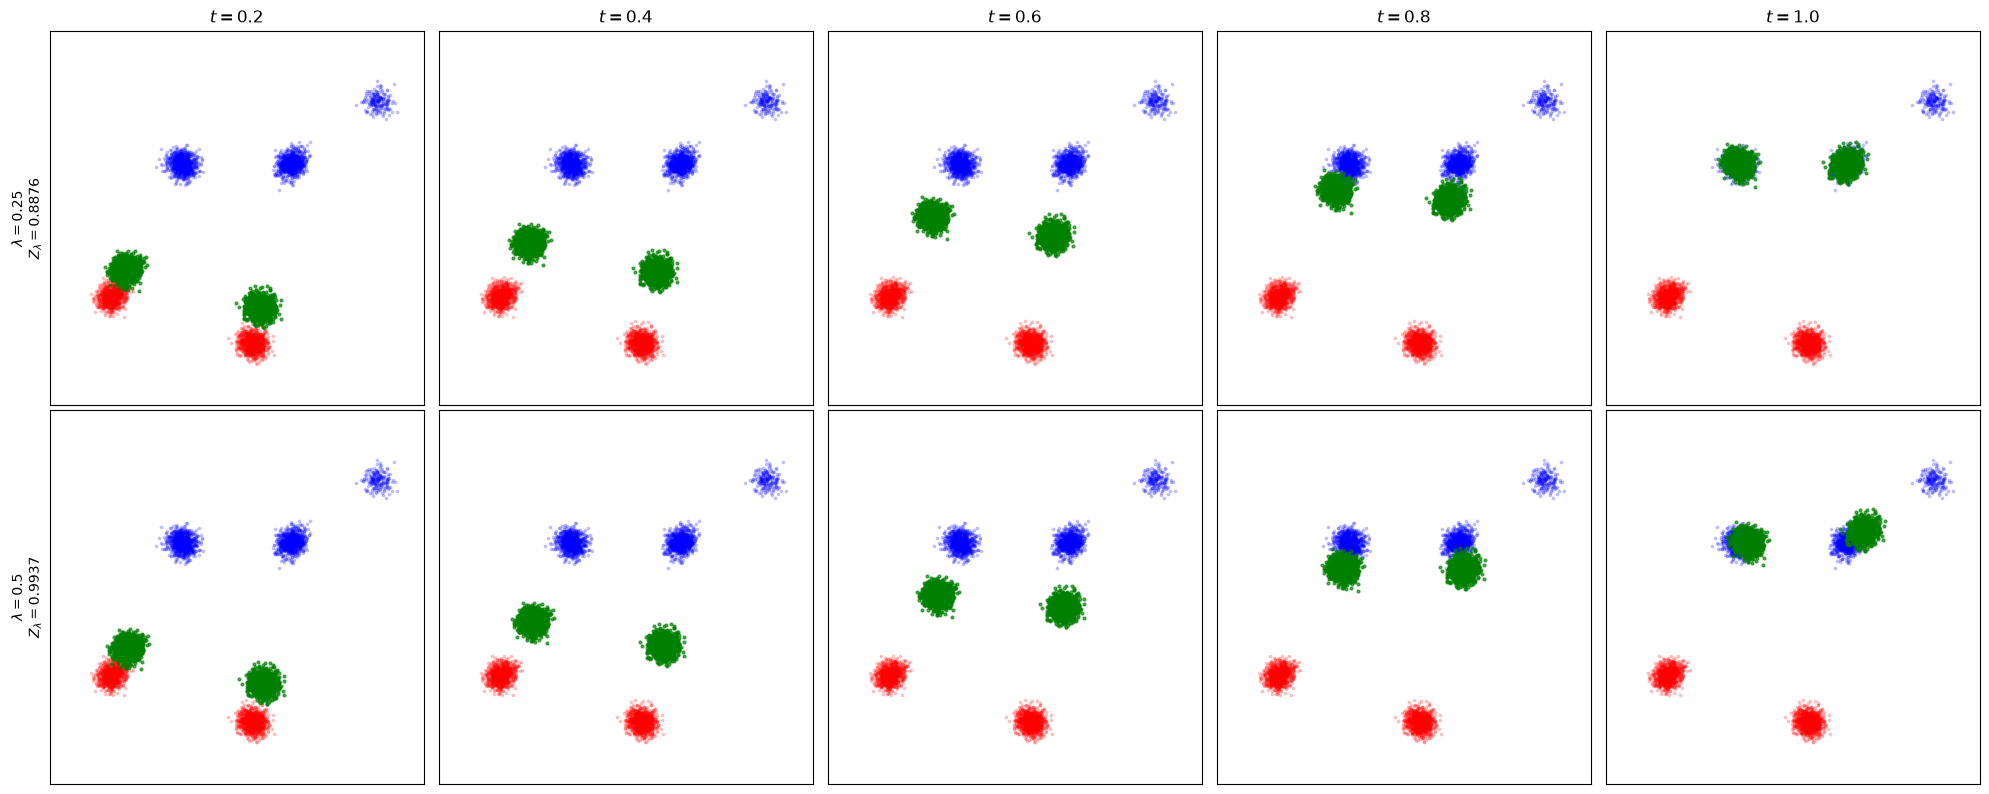

In [4]:
figure5 = make_figure5(
    source_points, target_points, figure5_records, times=FIGURE5_TIMES
)
figure5_path = OUTPUT_DIR / "figure5.pdf"
figure5.savefig(figure5_path, format="pdf", bbox_inches="tight", dpi=300)
write_figure_sidecar(
    METADATA_DIR / "figure5.json",
    figure=5,
    outputs=[figure5_path],
    panels=figure5_records,
    inputs={
        "source_gmm": {
            "weights": source.weights,
            "means": source.comp_mean,
            "covariances": source.comp_cov,
        },
        "target_gmm": {
            "weights": target.weights,
            "means": target.comp_mean,
            "covariances": target.comp_cov,
        },
        "source_evaluation_points": source_points,
        "target_plot_points": target_points,
        "times": FIGURE5_TIMES,
    },
    seeds={
        "source_sampling": DEFAULT_SEED + 10,
        "target_sampling": DEFAULT_SEED + 11,
        "fit": None,
    },
    notes="Known GMM parameters; canonical dummy-point EPOT and matched-density map (6.2).",
)
plt.show()
